# DANDI:001935 NWB Tutorial: Dopamine fiber photometry in nucleus accumbens and tail of striatum with 3D pose tracking during lone and social behavior in rats

This notebook demonstrates how to load and visualize a single session from the **Uchida Lab
Phillips 2025 / SFARI ARC** dataset converted to NWB, published as
[DANDI:001935](https://dandiarchive.org/dandiset/001935).

A subject is placed either alone ("Lone" session) or with another subject ("Social" session) in an arena and recorded with a **6-camera video system**. [TODO add fiberphotometry in this description]. 
3D body pose is tracked with **sDANNCE** (23 keypoints).
Each NWB file contains:

- `acquisition` — 6 `ImageSeries` (one per camera), pointing to the raw video files and 2      `FiberPhotometryResponseSeries` one per excitation channels (control/tdTomato
  568 nm, dopamine signal/GRABDA3m 473 nm), 2 fiber implants per session (NAc, TS).
- `processing/behavior/PoseEstimationSDANNCE` — 23 `PoseEstimationSeries` (one per body
  keypoint) giving 3D (x, y, z) trajectories for this rat
- `processing/behavior/Skeletons` — the keypoint graph (nodes + edges) used for pose
  estimation

The notebook has two ways to get an `nwbfile` to work with — pick whichever fits your
workflow:

1. **Stream directly from DANDI** — no download needed, works anywhere.
2. **Read a local NWB file** — fastest if you already have the file on disk (e.g. from
   the lab's data share), and lets us also open the companion video files.

Everything after that (file structure exploration and visualizations) works the same
regardless of which source you used.

## Setup

```bash
pip install dandi pynwb remfile h5py ndx-pose matplotlib pandas opencv-python-headless
```


In [1]:
# Core data manipulation and analysis
from pathlib import Path

import h5py

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import remfile
from dandi.dandiapi import DandiAPIClient

# NWB and DANDI access
from pynwb import NWBHDF5IO
from pynwb.image import ImageSeries

# Configure matplotlib
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# ndx-pose register the extension types used by this dataset with pynwb
# on import — they don't need to be called directly, just imported.
import ndx_pose  # noqa: F401

## Data Access Functions

## 1. Stream a session directly from DANDI

DANDI assets can be read directly over HTTP with [`remfile`](https://github.com/flatironinstitute/remfile),
without downloading the file to disk. This is the easiest way to explore the dataset if
you don't already have it locally.

We'll stream one session from **[DANDI:001936](https://dandiarchive.org/dandiset/001936)**.
Swap `dandiset_id` / `file_path` for any other subject/session in the Dandiset — use
`dandiset.get_assets()` to list them all.


In [2]:
def load_nwb_from_dandi(dandiset_id, subject_id, session_id, modality):
    """
    Load NWB file from DANDI Archive via streaming.
    """
    pattern = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_{modality}*.nwb"

    client = DandiAPIClient()
    client.dandi_authenticate()
    dandiset = client.get_dandiset(dandiset_id, "draft")
    assets = dandiset.get_assets_by_glob(pattern=pattern, order="path")

    s3_urls = []
    for asset in assets:
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)
        s3_urls.append(s3_url)

    if len(s3_urls) != 1:
        raise ValueError(f"Expected 1 file, found {len(s3_urls)} for pattern {pattern}")

    s3_url = s3_urls[0]

    file = remfile.File(s3_url)
    h5_file = h5py.File(file, "r")
    io = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwbfile = io.read()

    # Videos in NWB are stored as ImageSeries with external_file containing relative paths
    # We resolve them to full DANDI asset paths and get S3 URLs for streaming

    nwb_parent = Path(asset.path).parent
    video_s3_urls = {}

    for name, obj in nwbfile.acquisition.items():
        # Check for ImageSeries with external_file (videos stored externally)
        if isinstance(obj, ImageSeries) and obj.external_file is not None:
            # Get the relative path and resolve to full DANDI path
            relative_path = obj.external_file[0]
            full_path = f"{nwb_parent}/{relative_path}"

            # Fetch the video asset and get its S3 URL. Keep the query string (strip_query=False):
            # while the dandiset is in draft, the blob store requires the signed URL it carries --
            # a stripped URL returns 403 (both for direct HTTP access and for cv2.VideoCapture).
            video_asset = dandiset.get_asset_by_path(full_path)
            if video_asset is not None:
                video_s3_urls[name] = video_asset.get_content_url(
                    follow_redirects=1, strip_query=False
                )

    return nwbfile, io, video_s3_urls

## 2. Read a local NWB file

If the file is already on disk (e.g. mounted from the lab's data share), reading it is
just a standard `NWBHDF5IO` call.

In [3]:
def load_nwb_local(directory_path, subject_id, session_id, modality):
    """
    Load NWB file from local directory.
    """
    directory_path = Path(directory_path)
    nwbfile_path = directory_path / f"sub-{subject_id}_ses-{session_id}_{modality}.nwb"
    nwbfile_path =Path("H:/uchida-nwbfiles/sub-M4/sub-M4_ses-day-1-lone.nwb")

    if not nwbfile_path.exists():
        raise FileNotFoundError(f"NWB file not found: {nwbfile_path}")

    io = NWBHDF5IO(path=nwbfile_path, load_namespaces=True)
    nwbfile = io.read()

    video_file_paths = {}
    for name, obj in nwbfile.acquisition.items():
        # Check for ImageSeries with external_file (videos stored externally)
        if isinstance(obj, ImageSeries) and obj.external_file is not None:
            video_file_paths[name] = str(directory_path / obj.external_file[0])
    return nwbfile, io, video_file_paths

### Choose which source to explore

In [4]:
# Choose data source (DANDI streaming or local)
USE_DANDI = False  # Set to False to use local files
dandiset_id = "001935"
subject_id = "M4"
session_id = "day-1-lone"
modality = "image"
if USE_DANDI:
    nwbfile, io, video_s3_urls = load_nwb_from_dandi(dandiset_id, subject_id, session_id, modality)
else:
    # Specify your local directory path
    local_directory = f"H:/{dandiset_id}/sub-{subject_id}"  # Replace with actual path
    nwbfile, io, video_file_paths = load_nwb_local(local_directory, subject_id, session_id, modality)

## 3. Explore the file structure


In [5]:
print("Session description:", nwbfile.session_description)
print("Session start time: ", nwbfile.session_start_time)
print()

subject = nwbfile.subject
print("Subject ID:  ", subject.subject_id)
print("Species:     ", subject.species)
print("Strain:      ", subject.strain)
print("Genotype:    ", subject.genotype)
print("Sex:         ", subject.sex)
print("Date of birth:", subject.date_of_birth)
print("Description: ", subject.description)


Session description: Experimental day 1. Freely behaving rat in lone condition recorded with 6-camera multi-view video, 3D pose estimation (DANNCE), and fiber photometry (Doric BBC300). 
Session start time:  2024-06-24 13:58:40-04:00

Subject ID:   M4
Species:      Rattus norvegicus
Strain:       Long Evans
Genotype:     WT
Sex:          M
Date of birth: 2024-01-18 00:00:00-05:00
Description:  Experimental group: WT. Strain: Long Evans WT. Surgery date: 2024-05-01. Weight at experiment time: not recorded. SFARI Autism Rat Models Consortium (ARC).


In [6]:
print("acquisition:")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print()
print("processing modules:")
for module_name, module in nwbfile.processing.items():
    print(f"  {module_name}:")
    for name, obj in module.data_interfaces.items():
        print(f"    {name}: {type(obj).__name__}")


acquisition:
  FiberPhotometryRawControlSignal: FiberPhotometryResponseSeries
  FiberPhotometryRawDopamineSignal: FiberPhotometryResponseSeries
  SyncTTL_campy_trigger: TimeSeries
  VideoCamera1: ImageSeries
  VideoCamera2: ImageSeries
  VideoCamera3: ImageSeries
  VideoCamera4: ImageSeries
  VideoCamera5: ImageSeries
  VideoCamera6: ImageSeries

processing modules:
  behavior:
    PoseEstimationDANNCE: MultiCameraPoseEstimation
    Skeletons: Skeletons
  ophys:
    FiberPhotometryInterpolatedControl: FiberPhotometryResponseSeries
    FiberPhotometryInterpolatedDopamineSignal: FiberPhotometryResponseSeries


## 4. Visualize each data stream

### Fiber Photometry Hardware

In [7]:
fp_meta = nwbfile.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table

print("FiberPhotometryTable —", fp_table.description)
print()
fp_df = fp_table.to_dataframe()
# Simplify device columns to names only
for col in ["optical_fiber", "excitation_source", "photodetector", "indicator"]:
    if col in fp_df.columns:
        fp_df[col] = fp_df[col].apply(
            lambda x: x.name if hasattr(x, "name") else str(x)
        )
display_cols = [
    "location",
    "excitation_wavelength_in_nm",
    "emission_wavelength_in_nm",
    "optical_fiber",
    "excitation_source",
    "photodetector",
]
print(fp_df[[c for c in display_cols if c in fp_df.columns]].to_string())

FiberPhotometryTable — Fiber photometry channel configuration: 2 ROIs × 2 channels. NAc = Nucleus Accumbens, TS = Tail of Striatum. The control channel (568 nm) excites tdTomato; the dopamine_signal channel (473 nm) excites GRABDA3m. Both indicators co-injected at NAc and TS.

             location  excitation_wavelength_in_nm  emission_wavelength_in_nm      optical_fiber                  excitation_source       photodetector
id                                                                                                                                                     
0   Nucleus Accumbens                        568.0                      581.0  optical_fiber_NAc          excitation_source_control  photodetector_BFPD
1   Nucleus Accumbens                        473.0                      520.0  optical_fiber_NAc  excitation_source_dopamine_signal  photodetector_BFPD
2    Tail of Striatum                        568.0                      581.0   optical_fiber_TS          excitati

In [8]:
print("Optical fibers and implant coordinates:")
for name, dev in sorted(nwbfile.devices.items()):
    if not name.startswith("optical_fiber_"):
        continue
    ins = getattr(dev, "fiber_insertion", None)
    if ins is not None:
        ap = getattr(ins, "insertion_position_ap_in_mm", "?")
        ml = getattr(ins, "insertion_position_ml_in_mm", "?")
        dv = getattr(ins, "insertion_position_dv_in_mm", "?")
        hemi = getattr(ins, "hemisphere", "?")
        print(f"  {name}: AP={ap:+.2f}, ML={ml:+.2f}, DV={dv:.2f} mm  [{hemi}]")
    else:
        print(f"  {name}: no insertion coordinates")

print()
print("Excitation sources:")
for name in ("excitation_source_control", "excitation_source_dopamine_signal"):
    dev = nwbfile.devices.get(name)
    if dev is None:
        continue
    desc = getattr(dev, "description", None) or ""
    model = getattr(dev, "model", None)
    wl_range = getattr(model, "wavelength_range_in_nm", None)
    wl_str = (
        f" Wavelength range:  [{wl_range[0]:.1f}–{wl_range[-1]:.1f} nm]"
        if wl_range is not None
        else ""
    )
    print(f"  {name}: {desc.rstrip()}{wl_str}")

print()
print("Photodetectors:")
for name, dev in sorted(nwbfile.devices.items()):
    if not name.startswith("photodetector"):
        continue
    model = getattr(dev, "model", None)
    det_type = getattr(model, "detector_type", "?")
    gain = getattr(model, "gain", "?")
    gain_unit = getattr(model, "gain_unit", "")
    wl_range = getattr(model, "wavelength_range_in_nm", None)
    wl_str = f"{wl_range[0]:.0f}–{wl_range[-1]:.0f} nm" if wl_range is not None else "?"
    print(f"  {name}: type={det_type}, gain={gain} {gain_unit}, sensitivity={wl_str}")

print()
print("Indicator:")
for ind in fp_meta.fiber_photometry_indicators.indicators.values():
    print(f"  {ind.name} — label: {ind.label}, manufacturer: {ind.manufacturer}")

Optical fibers and implant coordinates:
  optical_fiber_NAc: AP=+1.15, ML=+2.20, DV=-6.30 mm  [unknown]
  optical_fiber_TS: AP=+3.15, ML=+5.20, DV=-4.50 mm  [unknown]

Excitation sources:
  excitation_source_control: Doric BBC300 control-channel LED (EXC1, 568 nm), modulated at 30 Hz. Excites tdTomato (red control fluorophore). Wavelength range:  [555.0–570.0 nm]
  excitation_source_dopamine_signal: Doric BBC300 dopamine-signal-channel LED (EXC2, 473 nm), modulated at 30 Hz with 16 ms phase offset relative to the control channel. Excites GRABDA3m (green dopamine sensor). Wavelength range:  [460.0–490.0 nm]

Photodetectors:
  photodetector_BFPD: type=CMOS, gain=1.0 AU, sensitivity=350–1100 nm

Indicator:
  GRABDA3m — label: GRABDA3m, manufacturer: WZ Biosciences
  tdTomato — label: tdTomato, manufacturer: Addgene


### Load FiberPhotometryResponseSeries and decode column → region mapping

In [9]:
fp_table = nwbfile.lab_meta_data["fiber_photometry"].fiber_photometry_table
fp_df = fp_table.to_dataframe()

ctrl_series = nwbfile.acquisition["FiberPhotometryRawControlSignal"]
sig_series = nwbfile.acquisition["FiberPhotometryRawDopamineSignal"]

for series in (ctrl_series, sig_series):
    n_samples, n_cols = series.data.shape
    row_idx = list(series.fiber_photometry_table_region.data[:])
    col_regions = [fp_df.iloc[i]["location"] for i in row_idx]
    print(f"{series.name}")
    if series.rate is not None:
        timing_str = (
            f"rate={series.rate:.2f} Hz, starting_time={series.starting_time:.4f} s"
        )
    else:
        t0, t1 = float(series.timestamps[0]), float(series.timestamps[-1])
        est_rate = (n_samples - 1) / (t1 - t0)
        timing_str = f"rate={est_rate:.2f} Hz (from timestamps), t0={t0:.4f} s"
    print(f"  shape={series.data.shape}, {timing_str}, unit={series.unit}")
    print(f"  columns: {col_regions}")
    print()

# Region list in column order (full Allen Atlas names) — used for plot labelling
regions = [
    fp_df.iloc[i]["location"] for i in ctrl_series.fiber_photometry_table_region.data[:]
]
print("Column → region:", regions)

FiberPhotometryRawControlSignal
  shape=(54456, 2), rate=30.12 Hz (from timestamps), t0=3.2160 s, unit=a.u.
  columns: ['Nucleus Accumbens', 'Tail of Striatum']

FiberPhotometryRawDopamineSignal
  shape=(54455, 2), rate=30.12 Hz (from timestamps), t0=3.2330 s, unit=a.u.
  columns: ['Nucleus Accumbens', 'Tail of Striatum']

Column → region: ['Nucleus Accumbens', 'Tail of Striatum']


### Plot raw fluorescence: all regions, both wavelengths

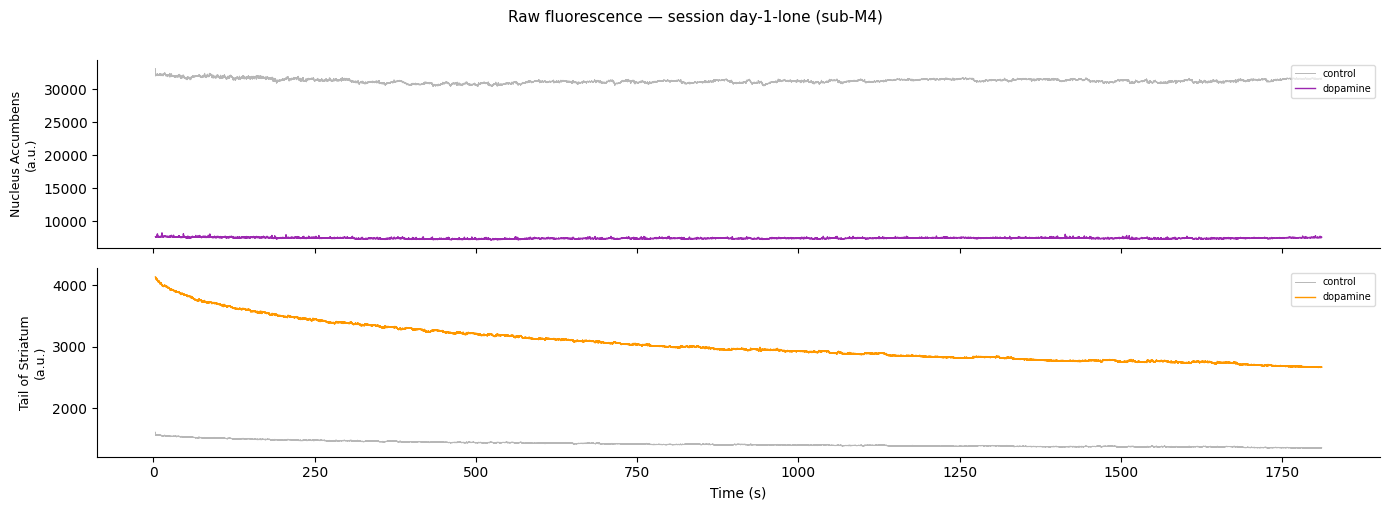

In [10]:
SIGNAL_COLOR = {
    "Nucleus Accumbens": "#9C27B0",
    "Tail of Striatum": "#FF9800",
}

ctrl_ts = ctrl_series.timestamps[:]
sig_ts = sig_series.timestamps[:]

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 2.5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for col_idx, (ax, region) in enumerate(zip(axes, regions)):
    color = SIGNAL_COLOR.get(region, "steelblue")
    ax.plot(
        ctrl_ts,
        ctrl_series.data[:, col_idx],
        color="#999",
        lw=0.7,
        alpha=0.7,
        label="control",
        rasterized=True,
    )
    ax.plot(
        sig_ts,
        sig_series.data[:, col_idx],
        color=color,
        lw=1.0,
        alpha=1.0,
        label="dopamine",
        rasterized=True,
    )
    ax.set_ylabel(f"{region}\n({ctrl_series.unit})", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Raw fluorescence — session {nwbfile.session_id} (sub-{nwbfile.subject.subject_id})",
    y=1.01,
    fontsize=11,
)
plt.tight_layout()
plt.show()

### Plot intrrerpolated signals

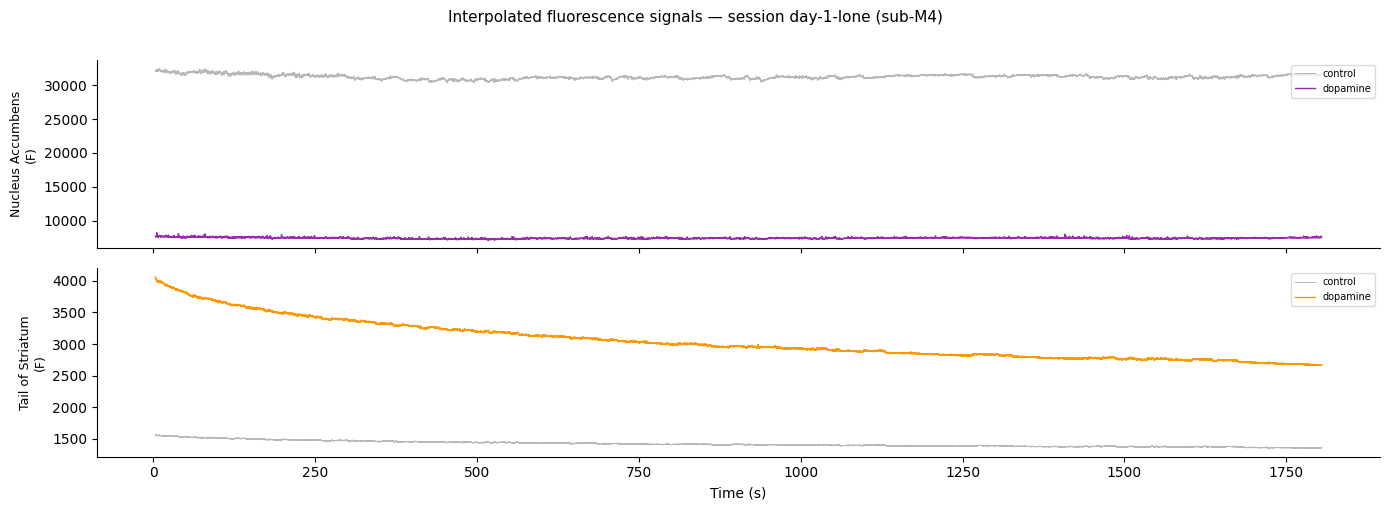

In [11]:
ctrl_int_series = nwbfile.processing["ophys"]["FiberPhotometryInterpolatedControl"]
sig_int_series = nwbfile.processing["ophys"]["FiberPhotometryInterpolatedDopamineSignal"]

SIGNAL_COLOR = {
    "Nucleus Accumbens": "#9C27B0",
    "Tail of Striatum": "#FF9800",
}

ctrl_int_ts = ctrl_int_series.get_timestamps()[:]
sig_int_ts = sig_int_series.get_timestamps()[:]

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 2.5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for col_idx, (ax, region) in enumerate(zip(axes, regions)):
    color = SIGNAL_COLOR.get(region, "steelblue")
    ax.plot(
        ctrl_int_ts,
        ctrl_int_series.data[:, col_idx],
        color="#999",
        lw=0.7,
        alpha=0.7,
        label="control",
        rasterized=True,
    )
    ax.plot(
        sig_int_ts,
        sig_int_series.data[:, col_idx],
        color=color,
        lw=1.0,
        alpha=1.0,
        label="dopamine",
        rasterized=True,
    )
    ax.set_ylabel(f"{region}\n({ctrl_int_series.unit})", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Interpolated fluorescence signals — session {nwbfile.session_id} (sub-{nwbfile.subject.subject_id})",
    y=1.01,
    fontsize=11,
)
plt.tight_layout()
plt.show()

### Video acquisition (6 cameras)

Each `ImageSeries` in `acquisition` points to a raw `.mp4` file rather than storing
pixel data inside the NWB file (`format="external"`). This keeps the NWB file small.
Pixel frames aren't accessible through `remfile`/`h5py` (that only streams the NWB
file itself) — but `cv2.VideoCapture` can read frames directly from the video, whether
it's a local file or a DANDI-hosted URL (see section 4e for an example).

In [12]:
for i in range(1, 7):
    series = nwbfile.acquisition[f"VideoCamera{i}"]
    print(f"VideoCamera{i}: {series.description} Hz")

VideoCamera1: Source video recorded by camera 'Camera1'. Recorded at a nominal 50 fps. Hz
VideoCamera2: Source video recorded by camera 'Camera2'. Recorded at a nominal 50 fps. Hz
VideoCamera3: Source video recorded by camera 'Camera3'. Recorded at a nominal 50 fps. Hz
VideoCamera4: Source video recorded by camera 'Camera4'. Recorded at a nominal 50 fps. Hz
VideoCamera5: Source video recorded by camera 'Camera5'. Recorded at a nominal 50 fps. Hz
VideoCamera6: Source video recorded by camera 'Camera6'. Recorded at a nominal 50 fps. Hz


In [13]:
if USE_DANDI:

    from IPython.display import HTML

    camera_to_display = "VideoCamera1"

    if camera_to_display in video_s3_urls:
        video_url = video_s3_urls[camera_to_display]
        display(HTML(f"""
        <video width="640" height="480" controls>
            <source src="{video_url}" type="video/mp4">
            Your browser does not support the video tag.
        </video>
        <p><b>{camera_to_display}</b></p>
        """))
    else:
        print(f"{camera_to_display} not available for this session")

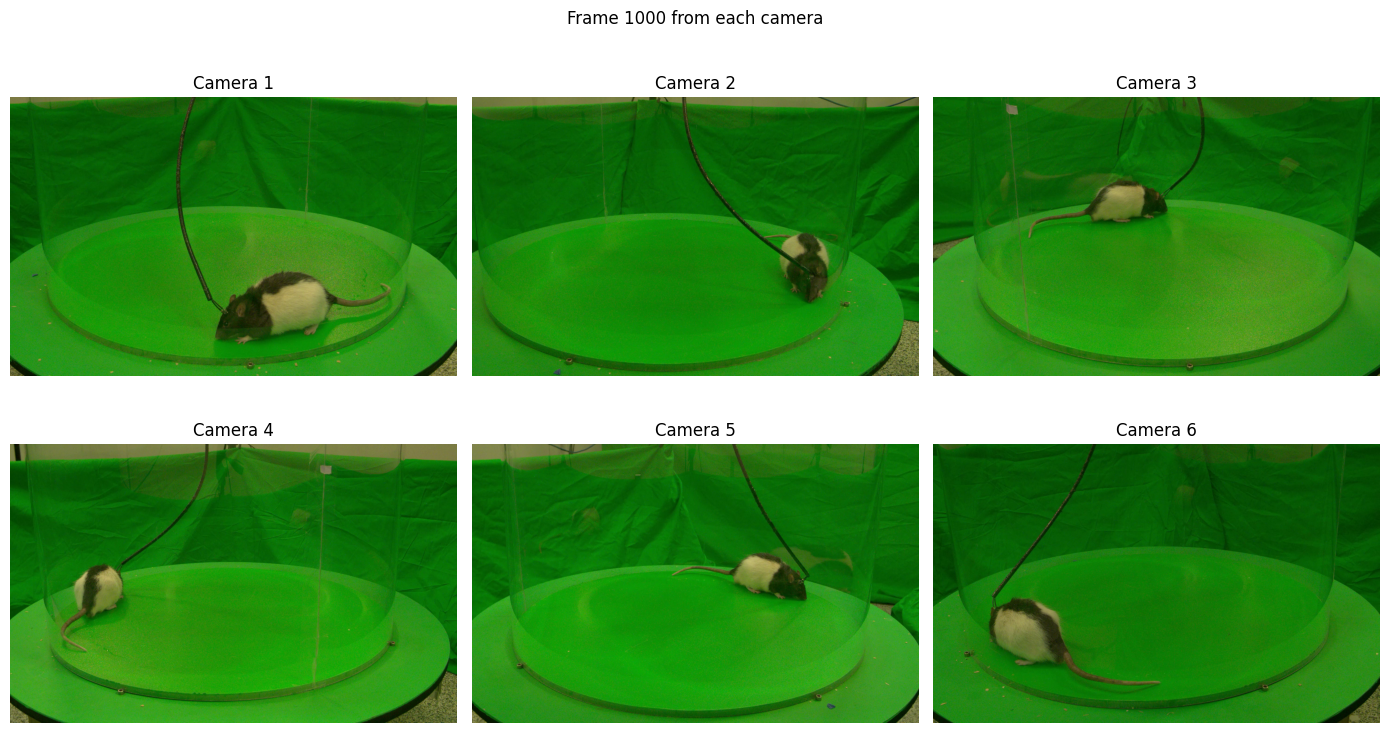

In [14]:
import cv2

if not USE_DANDI:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for i, ax in enumerate(axes.flat, start=1):
        cap = cv2.VideoCapture(video_file_paths[f"VideoCamera{i}"])
        cap.set(cv2.CAP_PROP_POS_FRAMES, 1000)  # an arbitrary frame partway through
        success, frame = cap.read()
        cap.release()

        if success:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Camera {i}")
        ax.axis("off")
    fig.suptitle("Frame 1000 from each camera")
    fig.tight_layout()

### 4b. 3D pose estimation (DANNCE)

`PoseEstimationSDANNCE` holds one `PoseEstimationSeries` per body keypoint, each an
`(n_frames, 3)` array of (x, y, z) coordinates in millimeters, sampled at ~50 Hz.


In [15]:
pose_estimation = nwbfile.processing["behavior"]["PoseEstimationDANNCE"]

keypoints = list(pose_estimation.pose_estimation_series.keys())
print(f"{len(keypoints)} keypoints:")
print(keypoints)


23 keypoints:
['PoseEstimationSeriesAnkleleft', 'PoseEstimationSeriesAnkleright', 'PoseEstimationSeriesEarleft', 'PoseEstimationSeriesEarright', 'PoseEstimationSeriesElbowleft', 'PoseEstimationSeriesElbowright', 'PoseEstimationSeriesFootleft', 'PoseEstimationSeriesFootright', 'PoseEstimationSeriesHandleft', 'PoseEstimationSeriesHandright', 'PoseEstimationSeriesHipleft', 'PoseEstimationSeriesHipright', 'PoseEstimationSeriesKneeleft', 'PoseEstimationSeriesKneeright', 'PoseEstimationSeriesShoulderleft', 'PoseEstimationSeriesShoulderright', 'PoseEstimationSeriesSnout', 'PoseEstimationSeriesSpinefront', 'PoseEstimationSeriesSpinelow', 'PoseEstimationSeriesSpinemiddle', 'PoseEstimationSeriesTailbase', 'PoseEstimationSeriesWristleft', 'PoseEstimationSeriesWristright']


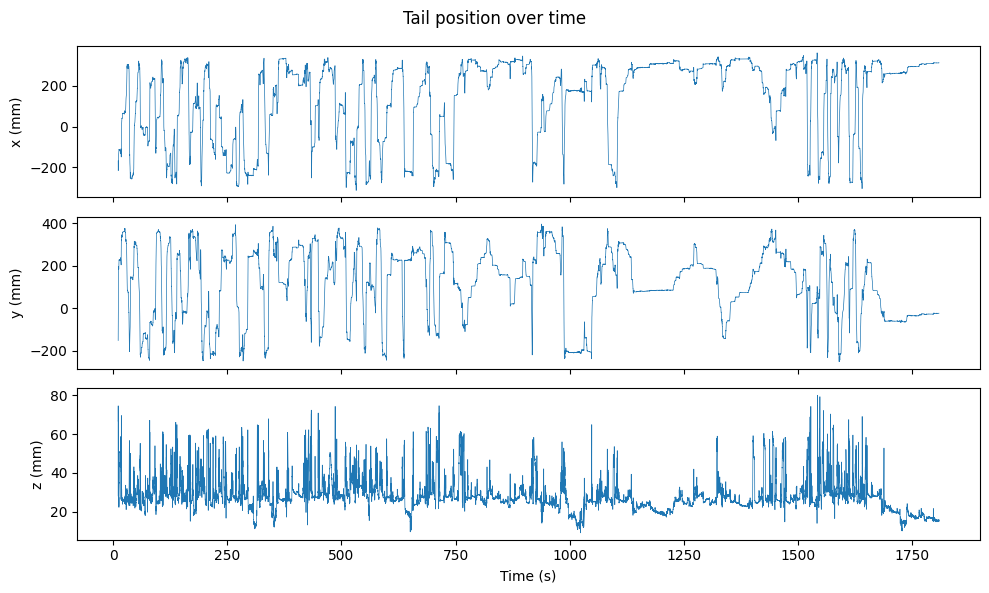

In [16]:
# XYZ trajectory of the snout over the whole session
tail = pose_estimation.pose_estimation_series["PoseEstimationSeriesTailbase"]
tail_xyz = tail.data[:]
t = tail.timestamps[:]

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, dim, label in zip(axes, range(3), ["x", "y", "z"]):
    ax.plot(t, tail_xyz[:, dim], linewidth=0.5)
    ax.set_ylabel(f"{label} (mm)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Tail position over time")
fig.tight_layout()

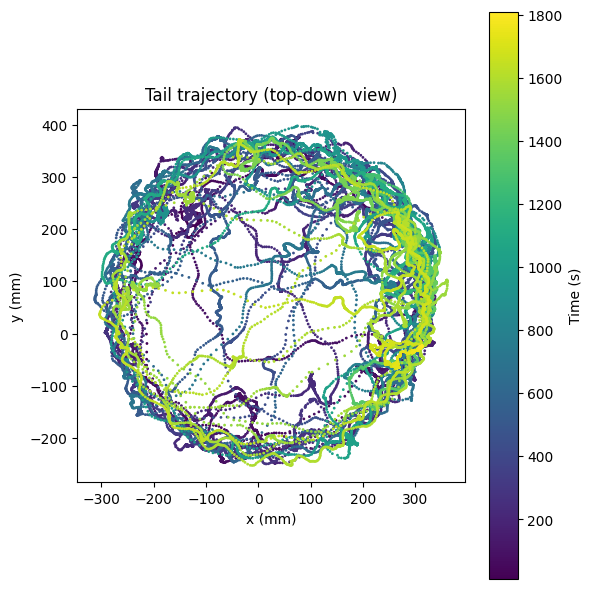

In [17]:
# Top-down (x, y) trajectory, colored by time
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(tail_xyz[:, 0], tail_xyz[:, 1], c=t, cmap="viridis", s=1)
fig.colorbar(sc, ax=ax, label="Time (s)")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_aspect("equal")
ax.set_title("Tail trajectory (top-down view)")
fig.tight_layout()

### 4c. Skeleton definition + a single pose frame

`Skeletons` describes the keypoint graph (nodes + edges) used for pose estimation. We
can combine it with the per-keypoint data above to draw the full 3D pose at a single
frame.


In [18]:
skeletons = nwbfile.processing["behavior"]["Skeletons"].skeletons
skeleton = skeletons["SkeletonPoseEstimationDANNCE_M4"]

nodes = skeleton.nodes[:]
edges = skeleton.edges[:]
print(f"{len(nodes)} nodes, {len(edges)} edges")
print(nodes)


23 nodes, 23 edges
['Snout' 'EarLeft' 'EarRight' 'SpineFront' 'SpineMiddle' 'SpineLow'
 'TailBase' 'ShoulderLeft' 'ElbowLeft' 'WristLeft' 'HandLeft'
 'ShoulderRight' 'ElbowRight' 'WristRight' 'HandRight' 'HipLeft'
 'KneeLeft' 'AnkleLeft' 'FootLeft' 'HipRight' 'KneeRight' 'AnkleRight'
 'FootRight']


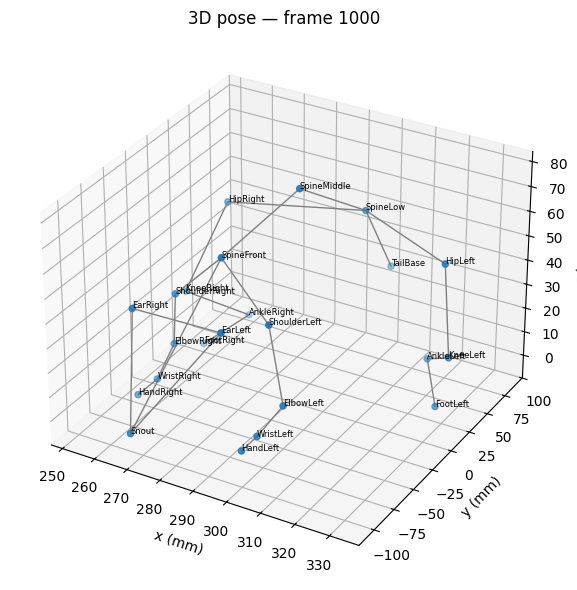

In [19]:
frame_idx = 1000

# gather (x, y, z) for every keypoint at this frame, in `nodes` order
coords = np.array(
    [pose_estimation.pose_estimation_series[f"PoseEstimationSeries{node.capitalize()}"].data[frame_idx]
     for node in nodes]
)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], color="tab:blue", s=20)
for node_i, node_j in edges:
    xs, ys, zs = coords[[node_i, node_j]].T
    ax.plot(xs, ys, zs, color="gray", linewidth=1)
for node_name, (x, y, z) in zip(nodes, coords):
    ax.text(x, y, z, node_name, fontsize=6)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("z (mm)")
ax.set_title(f"3D pose — frame {frame_idx}")
fig.tight_layout()

### 4d. Pose keypoints overlaid on a video frame

Each of the 6 cameras is geometrically calibrated: `nwbfile.devices` holds one
`ndx_pose.CalibratedCamera` per camera (`intrinsic_matrix`, `rotation_matrix`,
`translation_vector`, `distortion_coefficients`), and the same `CalibratedCamera` is linked
both from that camera's `ImageSeries` in `acquisition` (via `.device`) and from its
per-camera entry in `PoseEstimationSDANNCE`. That means the 3D keypoints (millimeters,
world coordinates) can be projected into any camera's 2D pixel space with
`cv2.projectPoints`, and drawn directly on top of the video frame they were estimated from.

We reuse the single-frame 3D pose (`coords`, `edges`) computed in section 4c above.
`cv2.VideoCapture` can read frames from either a local video file or the DANDI streaming
URL, so this works with both data-source options from section 1/2.

In [20]:
def project_points(points_3d, camera):
    """Project (n, 3) world-space points (mm) into a CalibratedCamera's 2D pixel coordinates.

    DANNCE calibration matrices are stored in MATLAB's row-vector convention
    (``x_cam = x_world @ r + t``, ``x_pixel ~ x_cam @ K``), which is the transpose of the
    column-vector convention OpenCV's `cv2.projectPoints` expects -- hence transposing
    `rotation_matrix`/`intrinsic_matrix` below.
    """
    rotation_vector, _ = cv2.Rodrigues(np.asarray(camera.rotation_matrix).T)
    translation_vector = np.asarray(camera.translation_vector)
    intrinsic_matrix = np.asarray(camera.intrinsic_matrix).T
    distortion_coefficients = (
        np.asarray(camera.distortion_coefficients) if camera.distortion_coefficients is not None else None
    )
    points_2d, _ = cv2.projectPoints(
        points_3d, rotation_vector, translation_vector, intrinsic_matrix, distortion_coefficients
    )
    return points_2d.reshape(-1, 2)

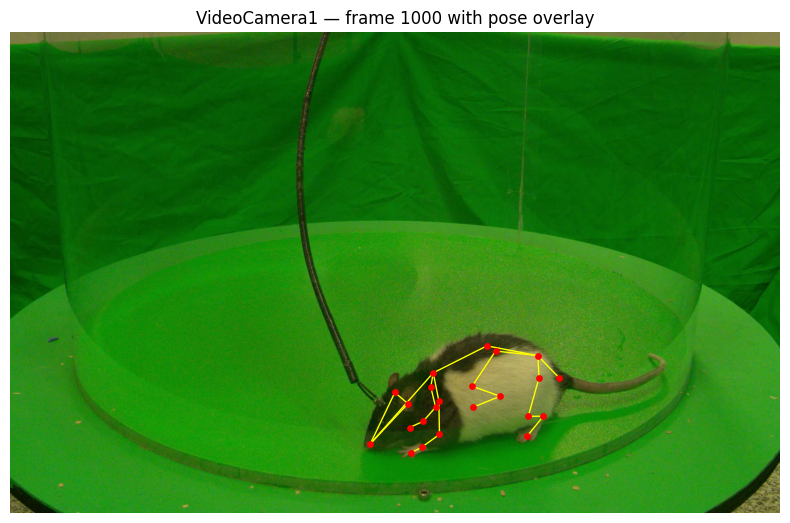

In [21]:
camera_to_display = "VideoCamera1"

video_source = video_s3_urls[camera_to_display] if USE_DANDI else str(
    video_file_paths[camera_to_display]
)
camera_device = nwbfile.acquisition[camera_to_display].device

cap = cv2.VideoCapture(video_source)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)  # frame_idx set in section 4c, kept in sync with `coords`
success, frame = cap.read()
cap.release()

if success:
    points_2d = project_points(coords, camera_device)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    for node_i, node_j in edges:
        xs, ys = points_2d[[node_i, node_j]].T
        ax.plot(xs, ys, color="yellow", linewidth=1)
    ax.scatter(points_2d[:, 0], points_2d[:, 1], color="red", s=15, zorder=3)
    ax.set_title(f"{camera_to_display} — frame {frame_idx} with pose overlay")
    ax.axis("off")
    fig.tight_layout()
else:
    print(f"Could not read frame {frame_idx} from {camera_to_display} ({video_source})")

### External ontology resources (HERD)

NWB files can carry machine-readable links from metadata values to entities in external
ontologies via HDMF's **HERD** (HDMF External Resources Data), stored in-file under
`/general/external_resources`. Instead of a bare free-text string like `"Rattus norvegicus"`
or `"Long-Evans"`, a HERD reference resolves that value to an unambiguous, resolvable term in a
controlled vocabulary - which is what lets archives like DANDI and other downstream tools
look up "what species / brain region is this, exactly" without guessing.

`neuroconv` populates this automatically during conversion for values it recognizes. In this
dataset:

- **Subject species** (`Rattus norvegicus`) → [**NCBI Taxonomy**](https://bioregistry.io/registry/ncbitaxon)
  (`NCBITaxon`), the standard taxonomic identifier system used across biomedical databases.
- **Subject strain** (`Long-Evans`) → [**RRID**](https://bioregistry.io/registry/rrid), the Research
  Resource Identifier for the rat strain.

`nwbfile.external_resources` is a `HERD` object; calling `.to_dataframe()` flattens it into
one row per `(object, key, entity)` reference.

In [22]:
from IPython.display import HTML

herd = nwbfile.external_resources

if herd is None:
    print("This NWB file has no external resources (ontology annotations).")
else:
    resources_df = herd.to_dataframe()[
        ["object_type", "relative_path", "field", "key", "entity_id", "entity_uri"]
    ].reset_index(drop=True)

    # Render entity_uri as a clickable link so the ontology term can be opened directly
    display_df = resources_df.copy()
    display_df["entity_uri"] = display_df["entity_uri"].apply(lambda uri: f'<a href="{uri}" target="_blank">{uri}</a>')
    display(HTML(display_df.to_html(escape=False, index=False)))

object_type,relative_path,field,key,entity_id,entity_uri
Subject,species,,Rattus norvegicus,NCBITaxon:10116,http://purl.obolibrary.org/obo/NCBITaxon_10116
Subject,strain,,Long Evans,RRID:RGD_2308852,https://scicrunch.org/resolver/RRID:RGD_2308852
VectorData,,,Nucleus Accumbens,UBERON:0001882,http://purl.obolibrary.org/obo/UBERON_0001882
VectorData,,,Tail of Striatum,UBERON:0002435,http://purl.obolibrary.org/obo/UBERON_0002435
Skeleton,nodes,,Snout,UBERON:0006333,http://purl.obolibrary.org/obo/UBERON_0006333
Skeleton,nodes,,EarLeft,UBERON:0001691,http://purl.obolibrary.org/obo/UBERON_0001691
Skeleton,nodes,,EarRight,UBERON:0001691,http://purl.obolibrary.org/obo/UBERON_0001691
Skeleton,nodes,,SpineFront,UBERON:0001130,http://purl.obolibrary.org/obo/UBERON_0001130
Skeleton,nodes,,SpineMiddle,UBERON:0001130,http://purl.obolibrary.org/obo/UBERON_0001130
Skeleton,nodes,,SpineLow,UBERON:0001130,http://purl.obolibrary.org/obo/UBERON_0001130


### Referenced ontologies

Each `entity_id` is a CURIE (`PREFIX:local_id`), e.g. `NCBITaxon:10116` or `UBERON:0008933`.
The prefix identifies which ontology the term comes from. The cell below inspects the
prefixes actually present in this file and prints a clickable link to each ontology's
registry page (via [Bioregistry](https://bioregistry.io/), a registry of ontology
namespaces), along with a short description.

In [23]:
# Short descriptions for the ontologies neuroconv can annotate with (see neuroconv.tools.ontology)
ONTOLOGY_INFO = {
    "NCBITaxon": ("NCBI Taxonomy", "Taxonomic identifiers (species) used across biomedical databases."),
    "UBERON": ("Uberon", "Cross-species anatomy ontology covering organs and gross anatomical structures."),
    "MBA": ("Allen Mouse Brain Atlas", "Structure ontology for the mouse brain."),
    "HBA": ("Allen Human Brain Atlas", "Structure ontology for the human brain."),
    "RRID": (
        "Research Resource Identifiers",
        "Identifiers for research resources, e.g. animal strains and antibodies.",
    ),
}

if herd is not None and not resources_df.empty:
    prefixes = sorted({entity_id.split(":")[0] for entity_id in resources_df["entity_id"]})

    rows = []
    for prefix in prefixes:
        name, description = ONTOLOGY_INFO.get(prefix, (prefix, ""))
        url = f"https://bioregistry.io/registry/{prefix.lower()}"
        rows.append(
            f'<li><a href="{url}" target="_blank"><b>{name}</b></a> ' f"(<code>{prefix}</code>) - {description}</li>"
        )

    display(HTML("<ul>" + "".join(rows) + "</ul>"))

## Summary

This notebook showed how to:

- Stream an NWB file directly from DANDI (no download) or read one from a local path
- Inspect a session's subject metadata, acquisition, processing modules
- Visualize fiber photometry hardware
- Plot raw and processed fiber photometry signals
- Visualize the 6-camera video acquisition
- Plot 3D pose trajectories and a full skeleton pose from sDANNCE tracking
- Project 3D pose keypoints into a camera's 2D pixel space using its calibration, and
  overlay them on a video frame
### Further resources

- [PyNWB documentation](https://pynwb.readthedocs.io/)
- [NWB overview](https://www.nwb.org/)
- [DANDI Archive documentation](https://www.dandiarchive.org/handbook/)
- [ndx-fiberphotometry extension](https://github.com/catalystneuro/ndx-fiber-photometry)
- [ndx-pose extension](https://github.com/rly/ndx-pose)